# 示例策略6: 指数增强选股策略

本策略以0.8为初始权重跟踪指数标的沪深300中权重大于0.35%的成份股.
个股所占的百分比为(0.8*成份股权重)*100%.然后根据个股是否:
1.连续上涨5天 2.连续下跌5天
来判定个股是否为强势股/弱势股,并对其把权重由0.8调至1.0或0.6

策略运行频率：每日运行
策略运行时间：每日收盘前

回测时间为:2021-01-01到2022-12-31

In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath('../'))
# 导入qteasy模块
import qteasy as qt
print(f'qteasy version: {qt.__version__}, datasource: {qt.QT_DATA_SOURCE}')

qteasy version: 2.0.0, datasource: mysql://localhost@3306/ts_db


In [2]:
# HS300成分股
shares = qt.filter_stock_codes(index='000300.SH', date='20210101')
share_info = qt.filter_stocks(index='000300.SH', date='20210101')
# 获取HS成分股的HS300权重
share_weights = qt.get_history_data(htypes='wt-000300.SH', shares=shares, start='20210101', end='20210501', freq='w', as_data_frame=False)

In [3]:
class IndexEnhancement(qt.GeneralStg):
    
    def __init__(self, pars: tuple = (0.35, 0.8, 5)):
        super().__init__(
                pars=pars,
                par_count=2,
                par_types=['float', 'float', 'int'],  # 参数1:沪深300指数权重阈值，低于它的股票不被选中，参数2: 初始权重，参数3: 连续涨跌天数，作为强弱势判断阈值
                par_range=[(0.01, 0.99), (0.51, 0.99), (2, 20)],
                name='IndexEnhancement',
                description='跟踪HS300指数选股，并根据连续上涨/下跌趋势判断强弱势以增强权重',
                strategy_run_timing='close',  # 在周期结束（收盘）时运行
                strategy_run_freq='d',  # 每天执行一次选股
                strategy_data_types='wt-000300.SH, close',  # 利用HS300权重设定选股权重, 根据收盘价判断强弱势
                data_freq='d',  # 数据频率（包括股票数据和参考数据）
                window_length=20,
                use_latest_data_cycle=True,
                reference_data_types='',  # 不需要使用参考数据
        )
    
    def realize(self, h, r=None, t=None, pars=None):

        weight_threshold, init_weight, price_days = self.pars
        # 读取投资组合的权重wt和最近price_days天的收盘价
        wt = h[:, -1, 0]  # 当前所有股票的权重值
        pre_close = h[:, -price_days - 1:-1, 1]
        close = h[:, -price_days:, 1]  # 当前所有股票的最新连续收盘价

        # 计算连续price_days天的收益
        stock_returns = pre_close - close  # 连续p天的收益
        
        # 设置初始选股权重为0.8
        weights = init_weight * np.ones_like(wt)
        
        # 剔除掉权重小于weight_threshold的股票
        weights[wt < weight_threshold] = 0
        
        # 找出强势股，将其权重设为1, 找出弱势股，将其权重设置为 init_weight - (1 - init_weight)
        up_trends = np.all(stock_returns > 0, axis=1)
        weights[up_trends] = 1.0
        down_trend_weight = init_weight - (1 - init_weight)
        down_trends = np.all(stock_returns < 0, axis=1)
        weights[down_trends] = down_trend_weight
        
        # 实际选股权重为weights * HS300权重
        weights *= wt

        return weights

419 ['000001.SZ', '000002.SZ', '000063.SZ', '000066.SZ', '000069.SZ', '000100.SZ', '000157.SZ', '000166.SZ', '000333.SZ', '000338.SZ']
No match found! To get better result, you can
- pass "match_full_name=True" to match full names of stocks and funds

     |                                  |
     |       BACK TESTING RESULT        |
     |                                  |

qteasy running mode: 1 - History back testing
time consumption for operate signal creation: 0.0 ms
time consumption for operation back looping:  13 sec 198.3 ms

investment starts on      2021-01-04 00:00:00
ends on                   2022-12-30 00:00:00
Total looped periods:     2.0 years.

-------------operation summary:------------
Only non-empty shares are displayed, call 
"loop_result["oper_count"]" for complete operation summary

          Sell Cnt Buy Cnt Total Long pct Short pct Empty pct
000001.SZ    0         3      3   100.0%     0.0%      0.0%  
000002.SZ    0         2      2   100.0%     0.0%      0.0

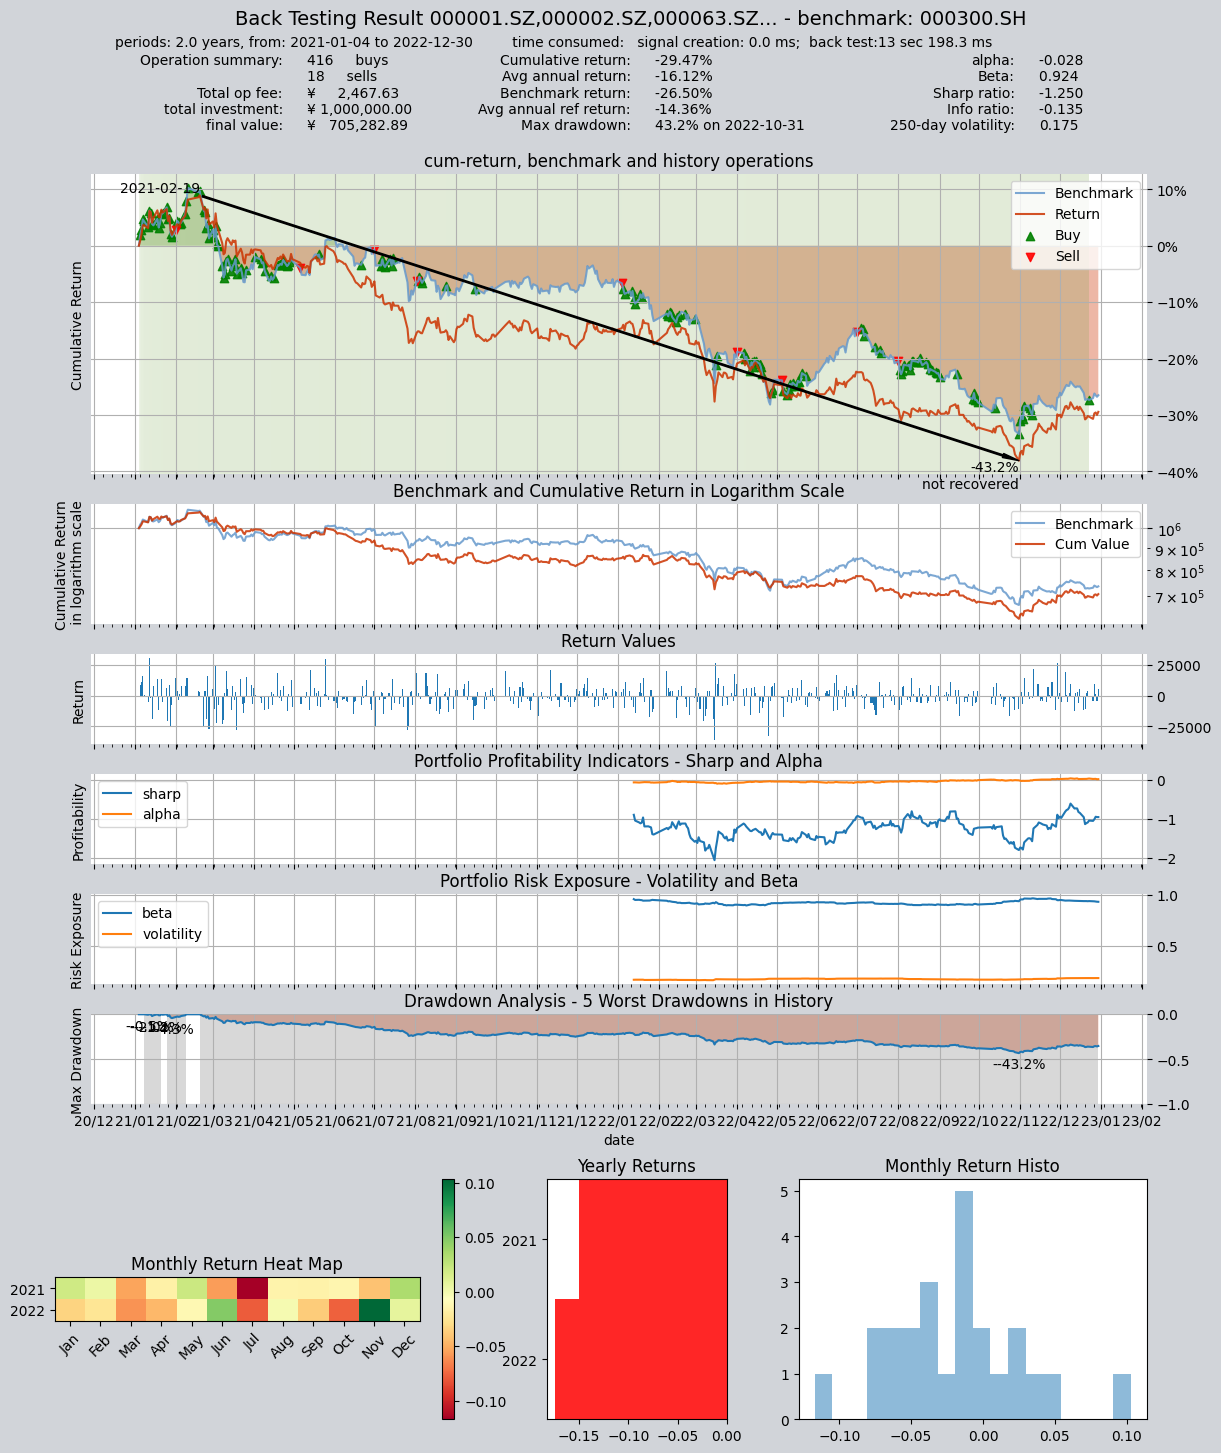

In [4]:
shares = qt.filter_stock_codes(index='000300.SH', date='20210101')
print(len(shares), shares[:10])
alpha = IndexEnhancement()
op = qt.Operator(alpha, signal_type='PT')
op.op_type = 'stepwise'
op.set_blender('1.0*s0', "close")
op.run(mode=1,
       invest_start='20210101',
       invest_end='20221231',
       invest_cash_amounts=[1000000],
       asset_type='E',
       asset_pool=shares,
       trade_batch_size=100,
       sell_batch_size=1,
       trade_log=True,
      )

print()